In [13]:
from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter
from pathlib import Path
from toolbox_continu_inzicht.dam_live.merge_stage_geometries_soils import merge_stage_geometries_soils
from toolbox_continu_inzicht.dam_live.merge_stage_water import merge_stage_water
from toolbox_continu_inzicht.dam_live.merge_stage_calculation import merge_stage_calculations
from toolbox_continu_inzicht.dam_live.plot_dam_live import plot_stage

In [3]:
config = Config(config_path=Path("data_sets/stix.yaml"))
config.lees_config()

adapter = DataAdapter(config)


In [4]:
df_stages = adapter.input("scenarios")

df_stages


,stage_id,stage_label,scenario_id,scenario_label,geometry_id,decorations_id,soillayers_id,waternet_id,waternet_creator_settings_id,state_id,state_correlations_id,loads_id,reinforcements_id,calculationsettings_id,calculation_id,content_version
0,22,Stage1,21,Scenario1,7,None,13,14,None,20,None,19,None,6,23,2


In [5]:
df_geometries = adapter.input("geometries")

df_geometries

,geometry_id,layer_id,layer_label,points,content_version
0,7,8,Surface 8,"[{'X': 35.82856255561803, 'Z': 1.1700000000000...",2
1,7,9,Surface 9,"[{'X': 40.637010954782866, 'Z': 1.17}, {'X': 4...",2
2,7,10,Surface 10,"[{'X': 56.99112854446494, 'Z': 1.17}, {'X': 61...",2
3,7,11,Surface 11,"[{'X': 61.146002420894135, 'Z': 1.17}, {'X': 1...",2
4,7,12,Surface 12,"[{'X': 41.642353673666406, 'Z': 0.669999999999...",2


In [6]:
df_soillayers = adapter.input("soillayers")

df_soillayers

,soillayers_id,layer_id,soil_id,content_version
0,13,8,0,2
1,13,9,1,2
2,13,10,0,2
3,13,11,1,2
4,13,12,2,2


In [7]:
df_soils = adapter.input("soils")

df_soils

,soil_id,name,code,color,volumetric_weight_above_phreatic_level,volumetric_weight_below_phreatic_level,shear_strength_model_type_above_phreatic_level,shear_strength_model_type_below_phreatic_level,mohr_coulomb_advanced_cohesion,mohr_coulomb_advanced_friction_angle,su_shear_strength_ratio,su_strength_increase_exponent,content_version
0,0,ClaS,ClaS-0,darkgreen,15.0,17.0,MohrCoulombAdvanced,MohrCoulombAdvanced,1.0,21.0,NaN,NaN,2
1,1,PeaU,PeaU-1,peru,5.0,13.0,MohrCoulombAdvanced,MohrCoulombAdvanced,1.5,20.0,NaN,NaN,2
2,2,SanB,SanB-2,lightgreen,18.0,20.0,MohrCoulombAdvanced,MohrCoulombAdvanced,0.0,30.0,NaN,NaN,2
3,3,ClaU,ClaU-3,green,9.0,14.5,MohrCoulombAdvanced,MohrCoulombAdvanced,2.0,25.0,NaN,NaN,2
4,4,klei,klei-4,sandybrown,15.0,16.5,MohrCoulombAdvanced,MohrCoulombAdvanced,2.0,25.0,NaN,NaN,2
5,5,SanN,SanN-5,yellow,9.0,14.5,MohrCoulombAdvanced,MohrCoulombAdvanced,2.0,19.0,NaN,NaN,2


In [8]:
df_waternets = adapter.input("waternets")

df_waternets

,waternet_id,line_type,line_id,line_label,x,z,top_headline_id,bottom_headline_id,content_version
0,14,Head,15,Phreatic line (PL 1),0.000000,0.120,None,None,2
1,14,Head,15,Phreatic line (PL 1),32.263564,0.120,None,None,2
2,14,Head,15,Phreatic line (PL 1),36.636805,-0.080,None,None,2
3,14,Head,15,Phreatic line (PL 1),40.139631,-0.380,None,None,2
4,14,Head,15,Phreatic line (PL 1),41.622247,-0.380,None,None,2
5,14,Head,15,Phreatic line (PL 1),41.642354,-0.500,None,None,2
6,14,Head,15,Phreatic line (PL 1),46.139940,-0.500,None,None,2
7,14,Head,15,Phreatic line (PL 1),113.138095,-0.500,None,None,2
8,14,Head,16,Head line 3 (PL 3),0.000000,-0.160,None,None,2
9,14,Head,16,Head line 3 (PL 3),31.641839,-0.160,None,None,2


In [9]:
df_calculationsettings = adapter.input("calculationsettings")

df_calculationsettings

,calculationsettings_id,analysis_type,calculation_type,model_factor_mean,model_factor_std,circle_center_x,circle_center_z,circle_radius,content_version
0,6,Bishop,Deterministic,1.0,0.0,42.919536,2.85125,3.72625,2


In [10]:
df_merged_soils = merge_stage_geometries_soils(df_stages, df_geometries, df_soillayers, df_soils)

df_merged_soils

,stage_id,stage_label,scenario_id,scenario_label,geometry_id,layer_id,layer_label,points,soillayers_id,soil_id,name,code,color
0,22,Stage1,21,Scenario1,7,8,Surface 8,"[{'X': 35.82856255561803, 'Z': 1.1700000000000...",13,0,ClaS,ClaS-0,darkgreen
1,22,Stage1,21,Scenario1,7,9,Surface 9,"[{'X': 40.637010954782866, 'Z': 1.17}, {'X': 4...",13,1,PeaU,PeaU-1,peru
2,22,Stage1,21,Scenario1,7,10,Surface 10,"[{'X': 56.99112854446494, 'Z': 1.17}, {'X': 61...",13,0,ClaS,ClaS-0,darkgreen
3,22,Stage1,21,Scenario1,7,11,Surface 11,"[{'X': 61.146002420894135, 'Z': 1.17}, {'X': 1...",13,1,PeaU,PeaU-1,peru
4,22,Stage1,21,Scenario1,7,12,Surface 12,"[{'X': 41.642353673666406, 'Z': 0.669999999999...",13,2,SanB,SanB-2,lightgreen


In [11]:
df_merged_water = merge_stage_water(df_stages, df_waternets)

df_merged_water

,stage_id,stage_label,scenario_id,scenario_label,waternet_id,line_type,line_id,line_label,x,z,top_headline_id,bottom_headline_id,content_version,color
0,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),0.000000,0.120,None,None,2,#ff1493
1,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),32.263564,0.120,None,None,2,#ff1493
2,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),36.636805,-0.080,None,None,2,#ff1493
3,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),40.139631,-0.380,None,None,2,#ff1493
4,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),41.622247,-0.380,None,None,2,#ff1493
5,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),41.642354,-0.500,None,None,2,#ff1493
6,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),46.139940,-0.500,None,None,2,#ff1493
7,22,Stage1,21,Scenario1,14,Head,15,Phreatic line (PL 1),113.138095,-0.500,None,None,2,#ff1493
8,22,Stage1,21,Scenario1,14,Head,16,Head line 3 (PL 3),0.000000,-0.160,None,None,2,#ff8c00
9,22,Stage1,21,Scenario1,14,Head,16,Head line 3 (PL 3),31.641839,-0.160,None,None,2,#ff8c00


In [12]:
df_merged_calculations = merge_stage_calculations(df_stages, df_calculationsettings)

df_merged_calculations

,stage_id,stage_label,scenario_id,scenario_label,calculationsettings_id,analysis_type,calculation_type,model_factor_mean,model_factor_std,circle_center_x,circle_center_z,circle_radius
0,22,Stage1,21,Scenario1,6,Bishop,Deterministic,1.0,0.0,42.919536,2.85125,3.72625


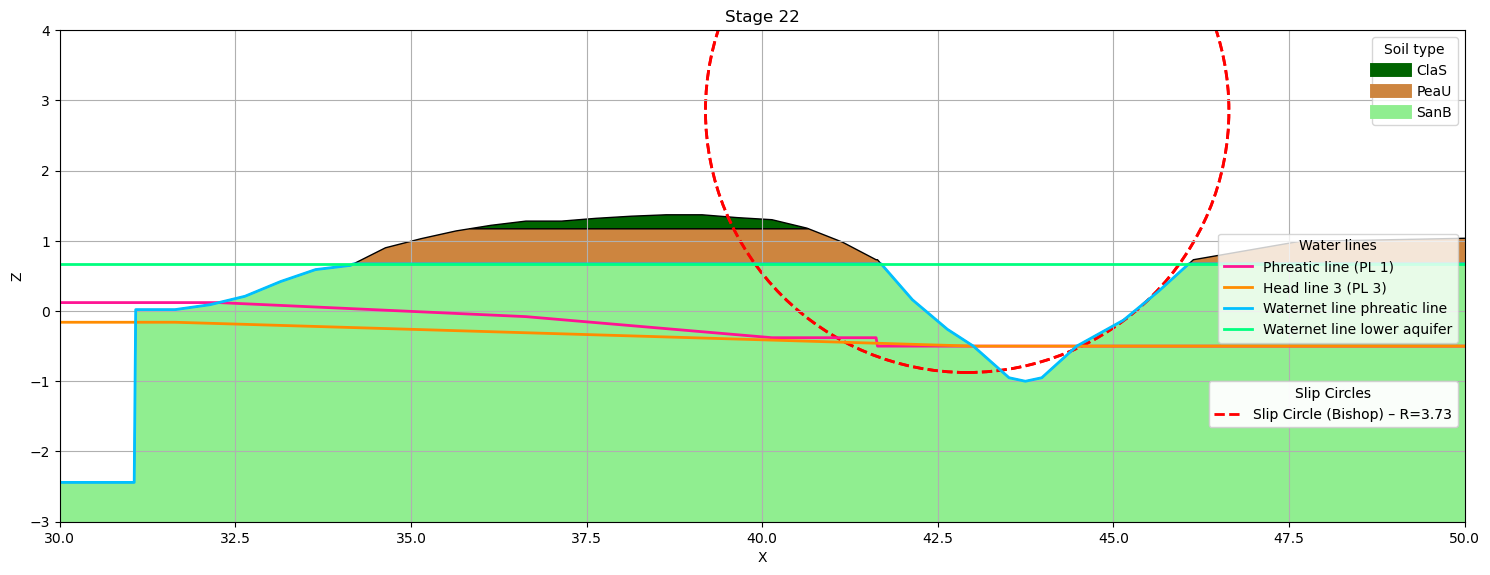

In [20]:
plot_stage(df_merged_soils, df_merged_water, df_merged_calculations, stage_id=22, xlim=(30, 50), ylim=(-3, 4))